## Introduction
For my notebook I will be analyzing the number of 311 calls in different Pittsburgh neighborhoods to find out which neighborhood is the most accessable. 
I define accessibility as the level of infrastructure and public service quality within a neighborhood. To measure this, I used Pittsburgh’s 311 Service Requests dataset from the Western Pennsylvania Regional Data Center.

My reasoning is that neighborhoods with fewer reported service requests likely have better maintained infrastructure, fewer public service issues, and more accessible public spaces  

Therefore, neighborhoods with fewer 311 complaints are considered more accessible.

## Dataset Used

**Dataset:** Pittsburgh 311 Service Requests  
**Source:** Western Pennsylvania Regional Data Center (WPRDC)

## Dataset Description
I used a dataset from the Western Pennsylvania Regional Data Center that shows the data of all the 311 calls in different neighborhoods in Pittsburgh. 311 calls are calls from the residents of Pittsburgh for non-emergency requests to improve or fix the quality of living in the area. An example of this could be to add more handicap parking spots a public parking lot. The columns for this are: 

    - _id: identification for the dataset
    - Case number
    - Status: open or closed
    - Case owner
    - Subject, Subject code
    - Legacy Subject
    - Date created / Date created (UTC)
    - Last updated / Last updated (UTC)
    - Date closed / Date closed (UTC)
    - Request Method
    - Street / Street ID
    - City
    - Neighborhood
    - Census tract
    - Counsil district
    - Ward
    - Police zone
    - Latitude / Longitude
    - Geoaccuracy
    - Unique ID

## Data Cleaning and Sorting

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data311 = pd.read_csv("dataset311.csv")

#sorting the data by neighborhood
sorted_data = data311.sort_values(by="neighborhood")

#cleaning the data to get rid of 311 calls not specific to a neighborhood
data_clean = sorted_data.dropna(subset=["neighborhood"])
data_clean = data_clean[~data_clean["neighborhood"].str.contains("Block Group", na=False)]

#organizing by the count of 311 calls
data_clean["neighborhood"].value_counts(ascending=True)


neighborhood
Chateau                    1
Ridgemont                  1
Southside Slopes           2
Arlington Heights          2
Fairywood                  3
                        ... 
Mount Washington         280
Beechview                291
Brookline                310
Central Lawrenceville    375
Carrick                  380
Name: count, Length: 91, dtype: int64

## Code Analysis

I started by sorting the dataset so that the neighborhoods are grouped together. Then I cleaned the data by not counting the general 311 calls that are non-neighborhood specific, and the not specified block groups. Finally I organized the dataset from smallest amount of 311 calls, to the largest number of 311 calls by neighborhood. 

From this information, we can tell that the neighborhoods with the fewest 311 calls are Chateau and Ridgemont with 1 311 call each, and the Southside Slopes and Arlington Heights with 2 311 calls each. 

## Visualization

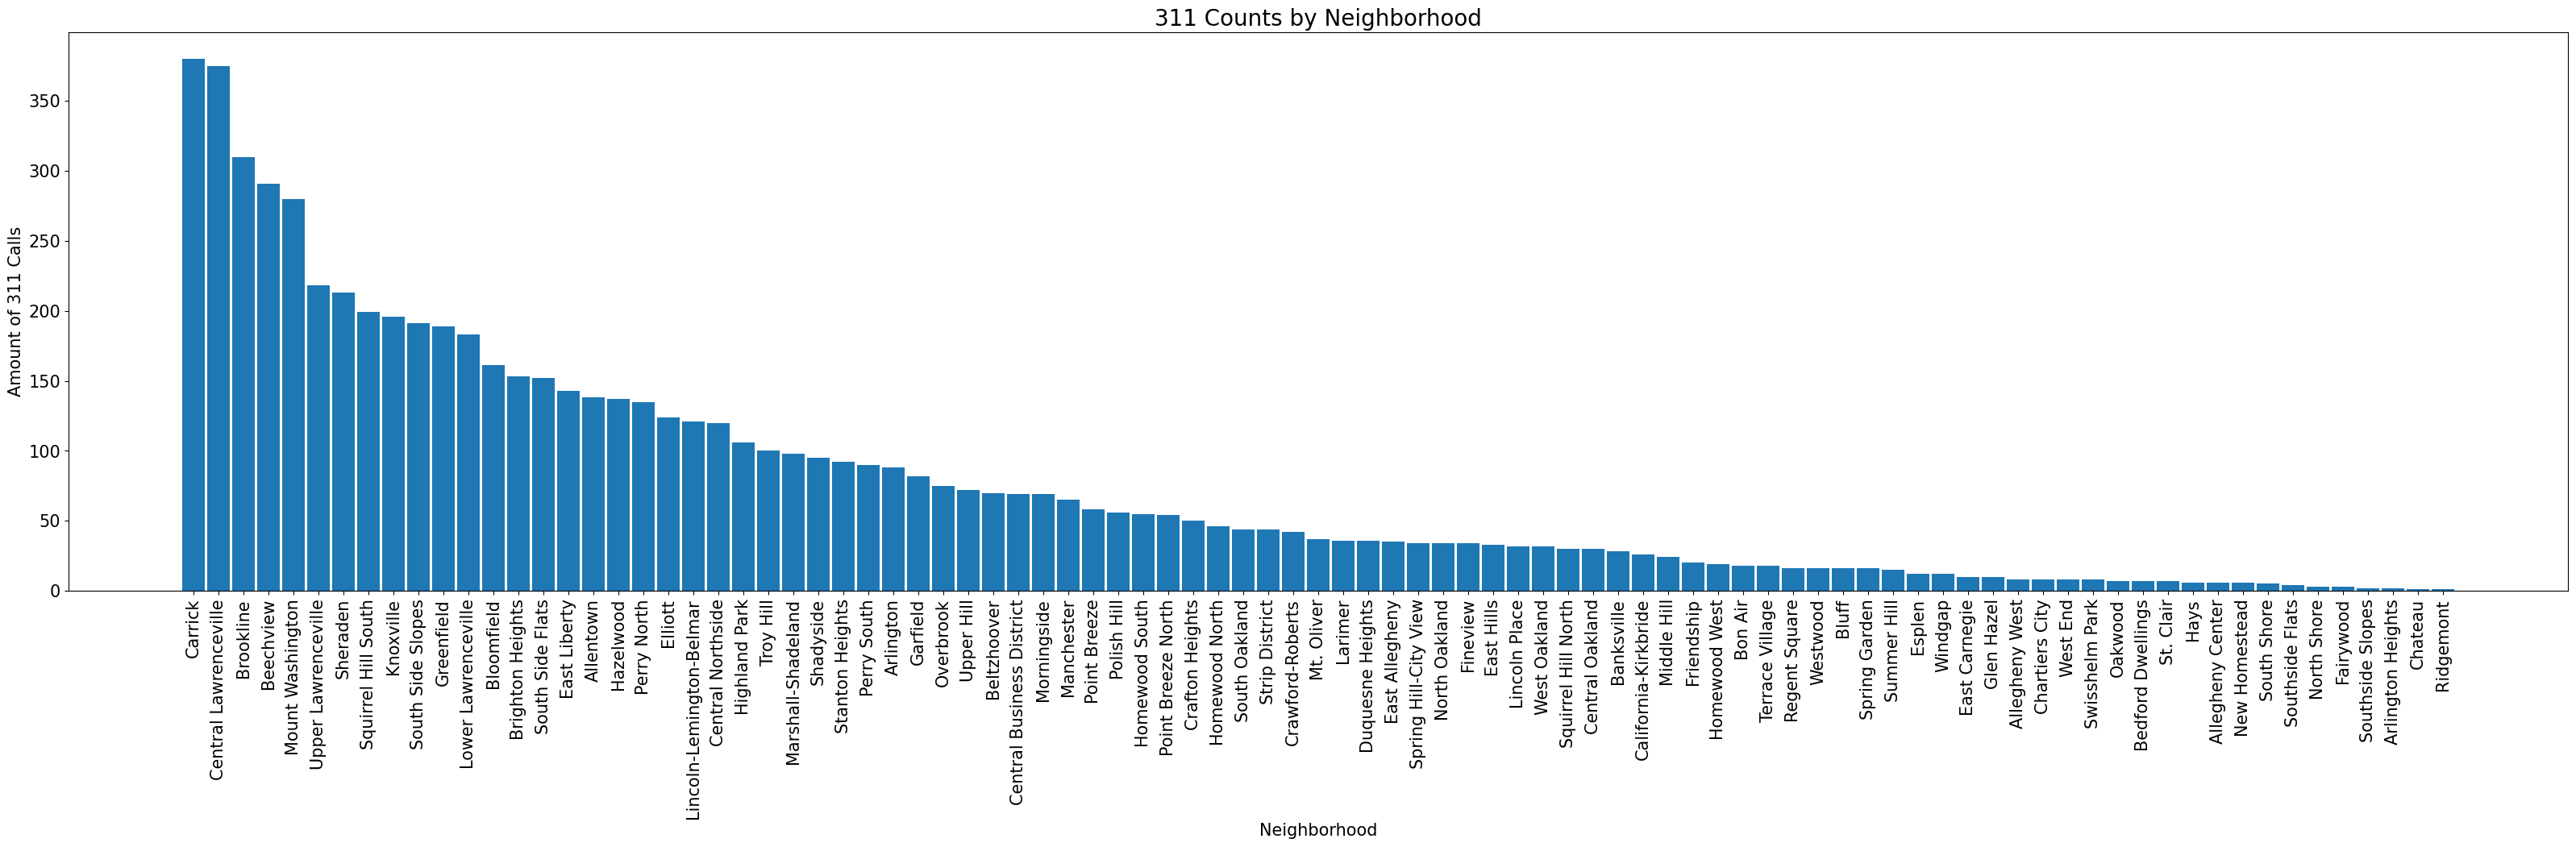

In [23]:
counts = data_clean["neighborhood"].value_counts()

plt.figure(figsize=(40,9))
plt.bar(counts.index, counts.values, width = .9)
plt.xticks(rotation=90, size = 15)
plt.yticks(size = 15)
plt.title("311 Counts by Neighborhood", size = 20)
plt.xlabel("Neighborhood", size = 15)
plt.ylabel("Amount of 311 Calls", size = 15)
plt.show()

This plot shows the amounts of 311 calls made by neighborhood. From this we can see that the 311 call amounts are drastically larger in the Carrick and Central Lawrenceville neighborhoods, with the neighborhoods being inversely proportional to the amount of 311 calls. 

## Conclusion

Using Pittsburgh’s 311 Service Requests data, I measured accessibility by counting neighborhood service complaints. Neighborhoods with fewer 311 requests were considered more accessible because they appear to experience fewer infrastructure and public service issues. The neighborhoods with the fewest 311 calls are Chateau and Ridgemont with only 1 311 call, and the Southside Slopes and Arlington Heights with 2 311 calls. The worst neighborhoods for accessibility being Carrick with 380 calls, and Central Lawrenceville with 375 calls. 

It is also important to mention that neighborhoods vary in sizes and population. With extra research, I found that the Carrick neighborhood is form about 10,000 - 15,000 residents, while Ridegemont only has around 300 - 700 residents. This likely does play a factor in the amount of 311 calls being made. The dataset did not have the populations of each other the neighborhoods, and I could not find another through WPRDC that showed the populations or sizes of the neighborhood. 

Overall, using amounts of 311 calls, the most accessible neighborhoods in Pittsburgh are Chateau and Ridgemont. 